## Imports

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree
from sklearn.model_selection import GroupKFold
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance

## Load model and data

In [2]:
with open('models/decision-tree-trained.pkl', 'rb') as file:
    dt_model = pickle.load(file)

In [72]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]
y_voice = data["Voice Disorders"].copy().to_numpy()
X_df = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders)
feature_names = X_df.columns
X = X_df.to_numpy()

In [4]:
feature_names = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).columns

## Train and test

In [5]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds

In [6]:
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

gkf = GroupKFold(n_splits=7,shuffle=False)
fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/test split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    dt_model.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = dt_model.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = dt_model.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[val_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
decision_tree_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
decision_tree_gkf_fold_results.head(10)

Per-fold GKF results (first 10 rows):


,fold,train_idx_count,val_idx_count,train_f1,val_f1,val_groups
0,0,14083,2346,0.661370,0.562863,"[1, 18, 27, 30, 31, 44, 45, 49, 50, 51, 56, 58..."
1,1,14100,2329,0.654211,0.614628,"[2, 13, 17, 21, 43, 44, 52, 55, 56, 68, 71, 72..."
2,2,14071,2358,0.671731,0.539828,"[3, 9, 12, 38, 39, 40, 48, 49, 53, 54, 55, 65,..."
3,3,14072,2357,0.642023,0.673666,"[0, 7, 11, 15, 20, 22, 26, 32, 35, 36, 40, 41,..."
4,4,14093,2336,0.657228,0.625572,"[14, 16, 19, 28, 33, 34, 51, 52, 61, 62, 63, 6..."
5,5,14074,2355,0.659582,0.653610,"[4, 5, 37, 46, 47, 59, 60, 68, 69, 70, 74, 75,..."
6,6,14081,2348,0.663932,0.635753,"[6, 8, 10, 23, 24, 25, 29, 37, 38, 42, 44, 45,..."


In [7]:
# final eval
y_test_preds = dt_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.69


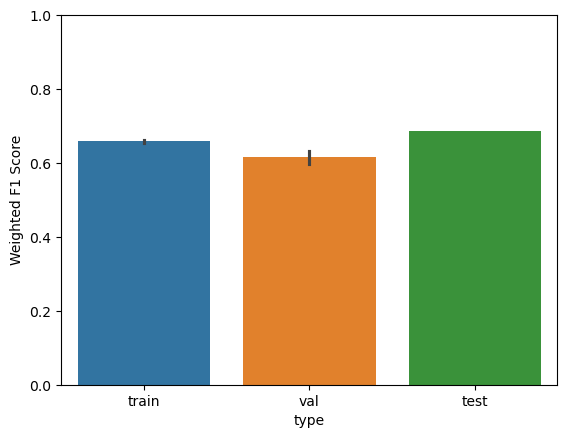

In [8]:
train_f1 = decision_tree_gkf_fold_results["train_f1"].mean()
val_f1 = decision_tree_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in decision_tree_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.ylabel("Weighted F1 Score")
plt.ylim([0, 1.0])
plt.show()

## Explainability

#### Tree structure

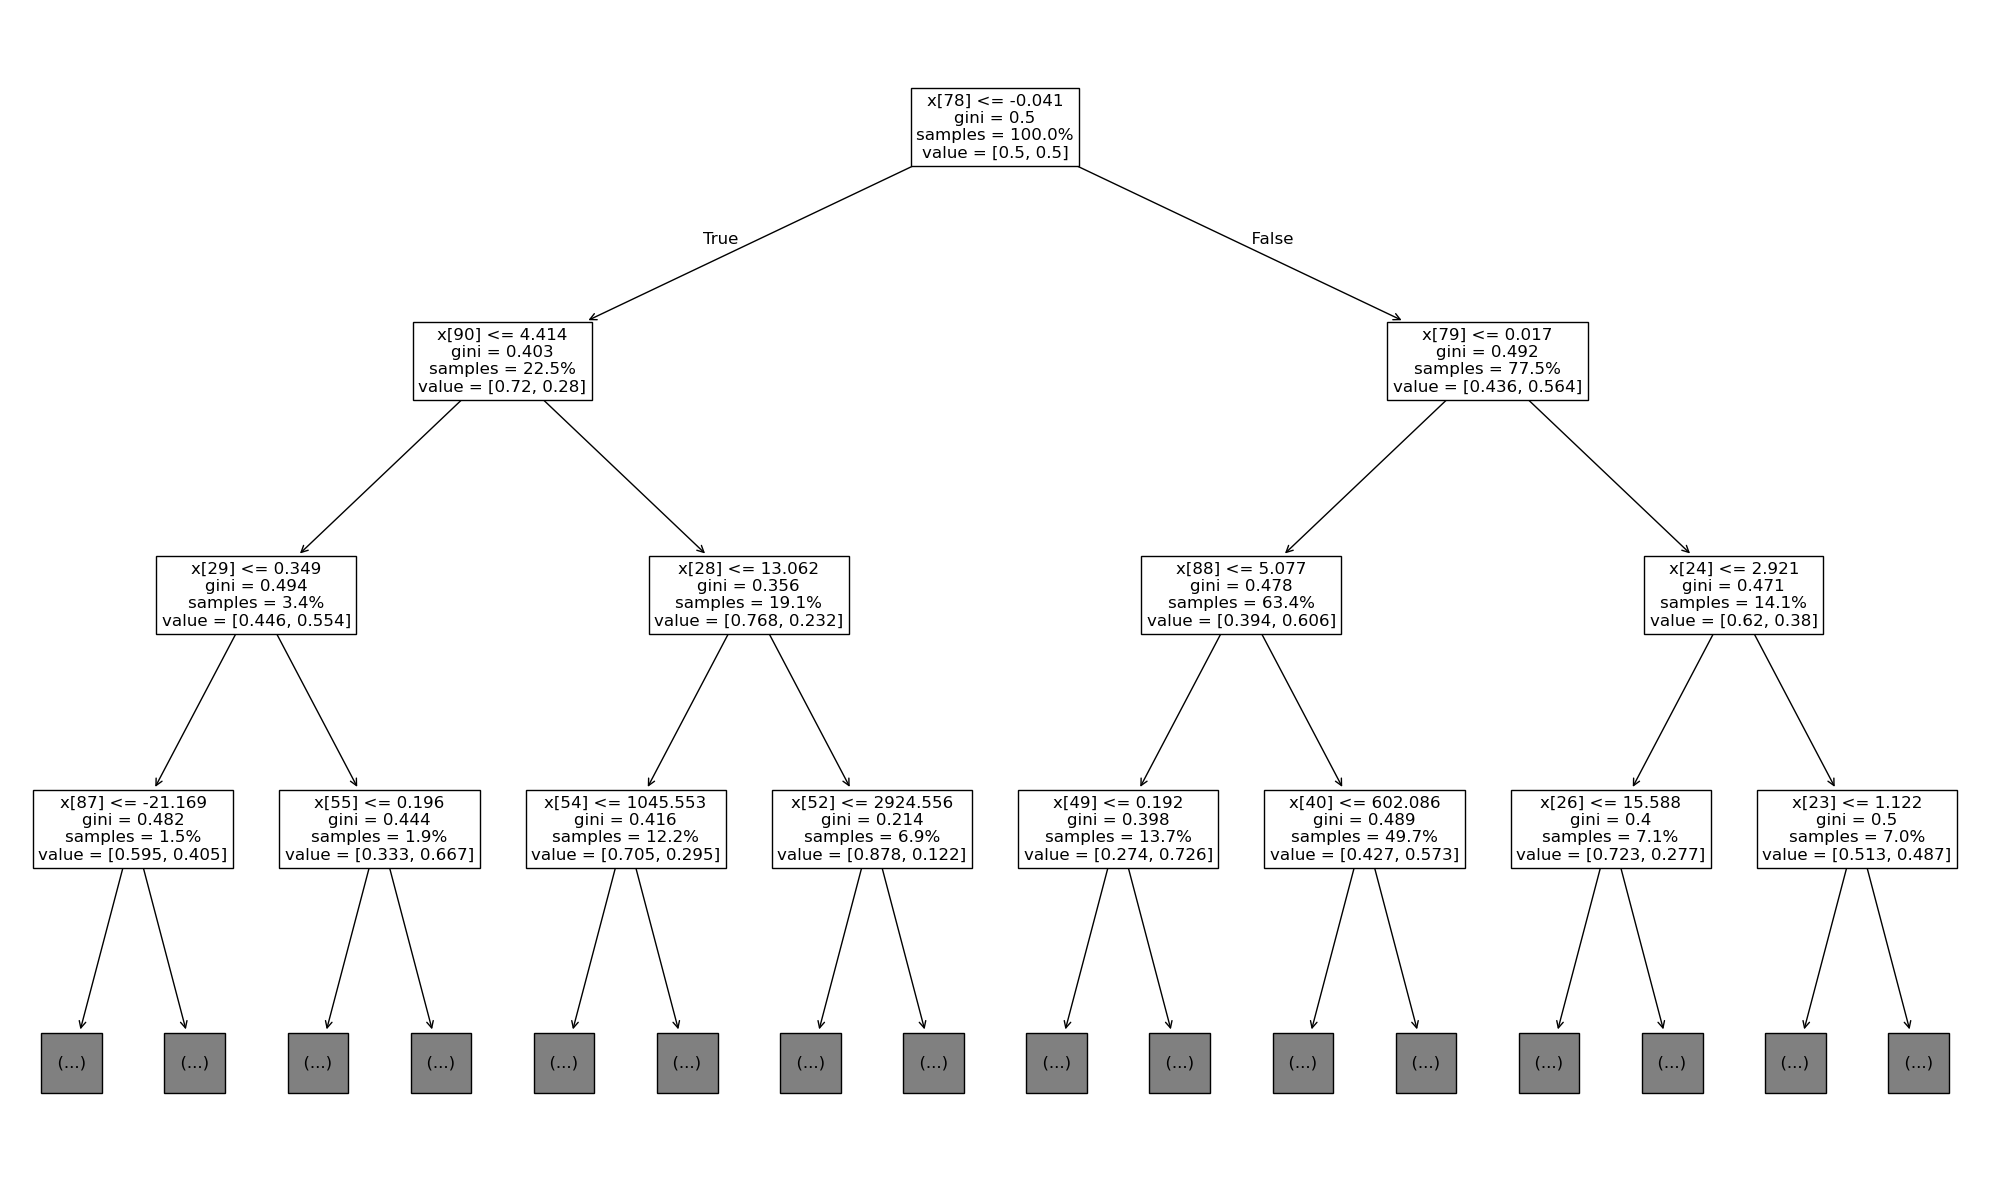

In [70]:
fig,ax = plt.subplots(1,1,figsize=(20,12))
tree.plot_tree(dt_model, proportion=True, max_depth=3, ax=ax,fontsize=12)
plt.tight_layout()
plt.show()

#### Gini impurity
- The impurity-based feature importances. The higher, the more important the feature. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature.

In [89]:
mdi_importances = pd.DataFrame.from_dict({
    "mdi":dt_model.feature_importances_, "feature":feature_names
}).sort_values(by="mdi",ascending=False)
mdi_importances

,mdi,feature
78,0.313372,slopeUV0-500_sma3nz_amean
79,0.129946,slopeUV500-1500_sma3nz_amean
90,0.072296,std_intensity_db
49,0.056868,F2bandwidth_sma3nz_stddevNorm
88,0.054998,duration
...,...,...
34,0.000000,HNRdBACF_sma3nz_amean
32,0.000000,shimmerLocaldB_sma3nz_amean
31,0.000000,jitterLocal_sma3nz_stddevNorm
30,0.000000,jitterLocal_sma3nz_amean


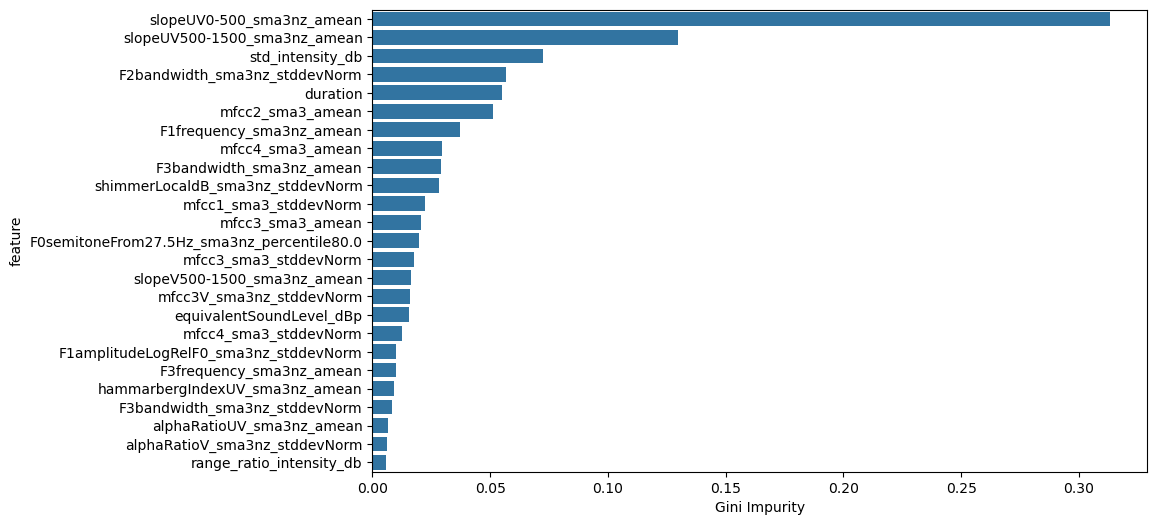

In [96]:
fig,ax = plt.subplots(1,1,figsize=(10,6))
sns.barplot(data=mdi_importances[:25],x="mdi",y="feature",orient="h")
ax.set_xlabel("Gini Impurity")
plt.show()

#### Permutation feature importance
- "Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset. This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model’s score [1]. By breaking the relationship between the feature and the target, we determine how much the model relies on such particular feature."

In [105]:
result = permutation_importance(
    dt_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
importances

,mfcc1_sma3_stddevNorm,mfcc4_sma3_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_amean,slopeV0-500_sma3nz_stddevNorm,slopeV0-500_sma3nz_amean,hammarbergIndexV_sma3nz_stddevNorm,hammarbergIndexV_sma3nz_amean,alphaRatioV_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_amean,...,equivalentSoundLevel_dBp,F2bandwidth_sma3nz_stddevNorm,std_intensity_db,duration,mfcc4_sma3_amean,mfcc2_sma3_amean,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F1frequency_sma3nz_amean,slopeUV500-1500_sma3nz_amean,slopeUV0-500_sma3nz_amean
0,-0.001843,-0.000307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003378,0.005528,0.007371,0.008907,0.012592,0.023956,0.024263,0.035627,0.029484,0.103501
1,-0.002150,-0.003071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002150,0.003071,0.004914,0.008600,0.012592,0.019656,0.026106,0.031941,0.041462,0.092138
2,-0.001843,0.000614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003071,0.006757,0.005528,0.008292,0.011364,0.018735,0.029484,0.035627,0.039926,0.108415
3,-0.001536,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003686,0.000921,0.004300,0.014128,0.011057,0.021806,0.035319,0.027334,0.035319,0.090909
4,-0.002457,-0.000614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.005528,0.006757,0.005221,0.003686,0.012285,0.019656,0.030405,0.033784,0.039312,0.088145
5,-0.001843,-0.003071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003686,0.006757,0.006757,0.007371,0.012285,0.016892,0.036241,0.030098,0.030713,0.089681
6,-0.000921,-0.002764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003993,0.006143,0.007678,0.004607,0.011978,0.022113,0.037162,0.031020,0.039619,0.096744
7,-0.002457,0.000307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.006143,0.006143,0.003378,0.011978,0.013206,0.020577,0.030098,0.029177,0.036241,0.090295
8,-0.000921,-0.001536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.004607,0.003378,0.008292,0.010135,0.012592,0.019349,0.039312,0.037776,0.031941,0.100737
9,-0.001536,-0.001843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001536,0.003993,0.006757,0.013206,0.011978,0.023342,0.035012,0.034705,0.037776,0.095823


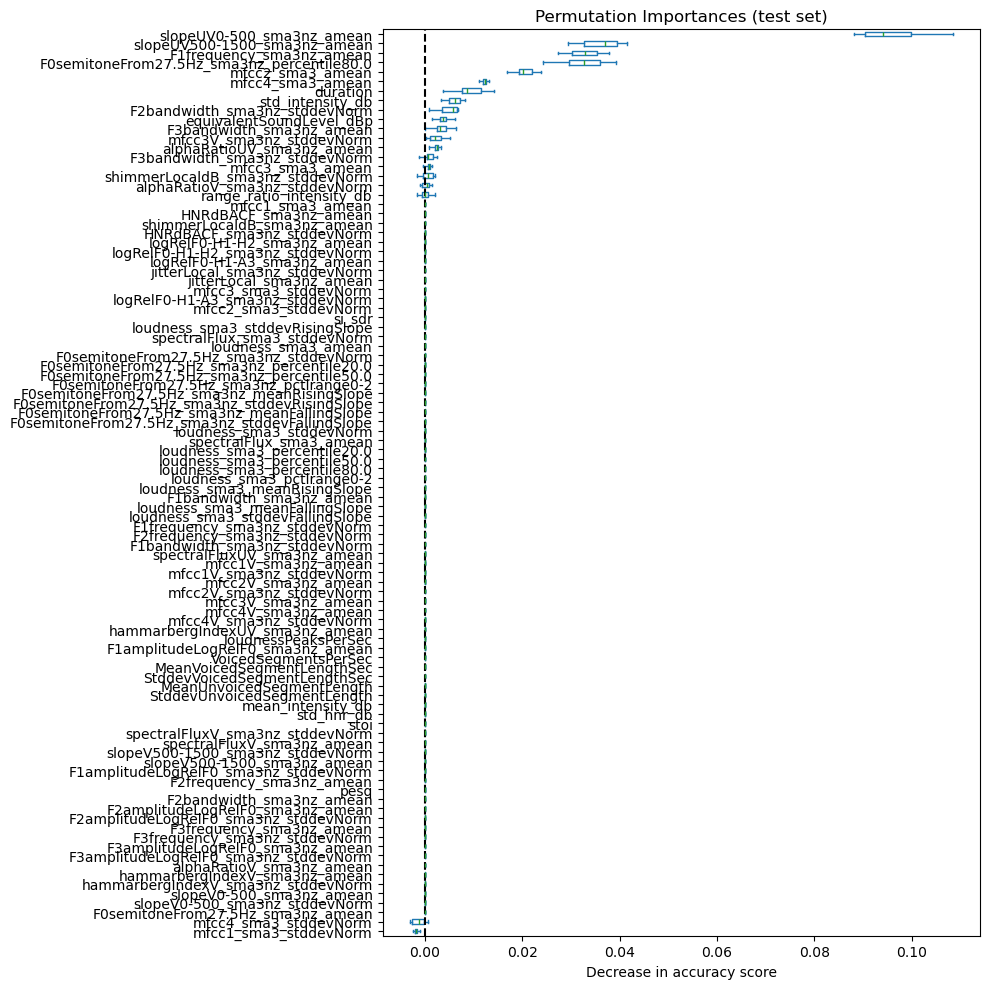

In [118]:
ax = importances.plot.box(vert=False, whis=10, figsize=(10,10))
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()

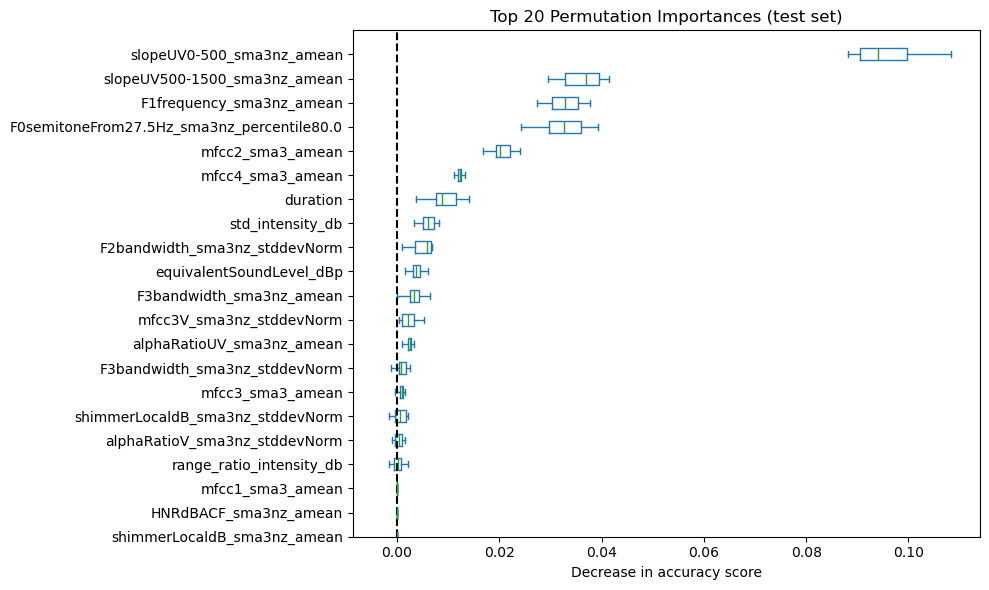

In [115]:
ax = importances.plot.box(vert=False, whis=10, figsize=(10,6))
ax.set_title("Top 20 Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.set_ylim([len(feature_names)-20,len(feature_names)+1])
ax.figure.tight_layout()

#### Check permutation feature importance for training set too

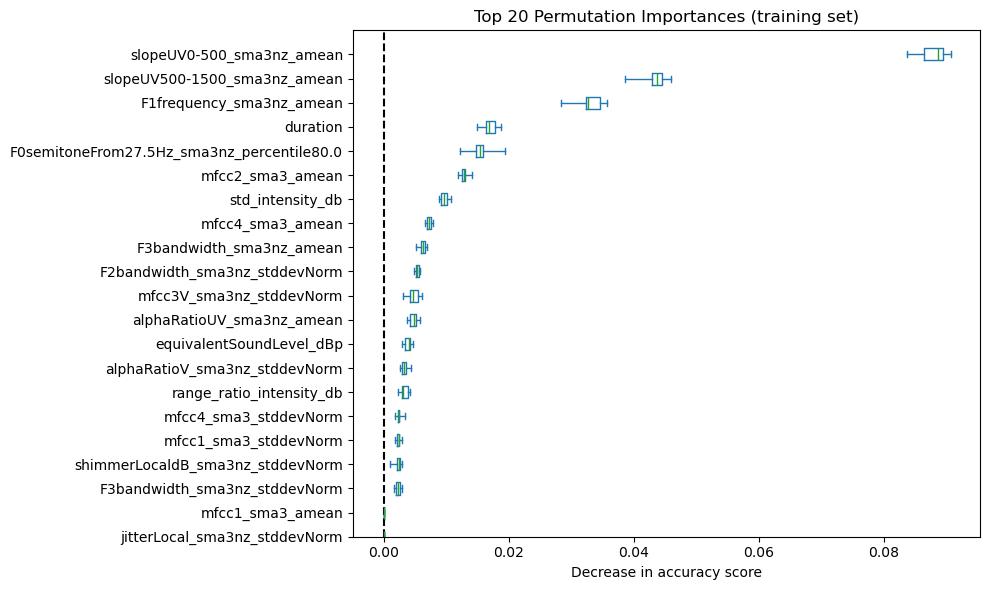

In [120]:
result = permutation_importance(
    dt_model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)

ax = importances.plot.box(vert=False, whis=10, figsize=(10,6))
ax.set_title("Top 20 Permutation Importances (training set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.set_ylim([len(feature_names)-20,len(feature_names)+1])
ax.figure.tight_layout()